# K-Means Clustering

Ky notebook aplikon **K-Means** mbi te dhenat e shtepive per te identifikuar grupe (segmente) natyrale shtepish me karakteristika te ngjashme.

Per clustering perdorim dataset-in `train_regression_dataset.csv` (i shkallezuar), duke hequr target-in `price`, sepse K-Means eshte nje algoritem **unsupervised** dhe nuk perdor target-in per te mesuar grupimet.

Pas formimit te clusterave, analizojme `price` mesatar per cdo cluster per te kuptuar nese grupimet kane lidhje me cmimin e shtepise.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

sns.set_theme(style="whitegrid")

## 1. Leximi i dataset-it

Perdorim `train_regression_dataset.csv` sepse permban target-in numerik `price`, qe na duhet vetem per analize pas clustering-ut, jo per trajnim.

In [7]:
data_dir = Path("../../data/processed")

train_df = pd.read_csv(data_dir / "train_regression_dataset.csv")

print("Train shape:", train_df.shape)
train_df.head()

Train shape: (12810, 53)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,is_luxury_grade,is_high_view,is_premium,waterfront_grade,waterfront_sqft_living,view_grade,view_sqft_living,grade_lat_bin,grade_location_cluster,price
0,-0.400877,-1.474831,-1.014044,-0.225976,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.736541,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-0.413012,221900.0
1,-0.400877,0.205526,-0.386572,-0.196899,0.948224,-0.073053,-0.297197,-0.637474,-0.552387,-0.057074,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-1.675403,-0.265497,257500.0
2,-0.400877,-1.474831,-0.310337,-0.180706,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.901645,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-1.150589,229500.0
3,-0.400877,0.541597,1.777328,-0.122849,-0.905392,-0.073053,-0.297197,-0.637474,0.332676,0.127080,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,1.905088,662500.0
4,-1.515537,-1.474831,-1.037501,-0.217270,-0.905392,-0.073053,-0.297197,0.886894,-0.552387,-1.142951,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,-0.855558,468000.0


## 2. Pergatitja e te dhenave

Heqim kolonen `price` nga veçorite, sepse K-Means perdor vetem `X` per te formuar grupimet. `price` ruhet vec per analize me vone.

In [8]:
target_col = "price"

X = train_df.drop(columns=[target_col])
price = train_df[target_col]

print("Features:", X.shape[1])
print("Samples:", X.shape[0])

Features: 52
Samples: 12810


## 3. Eksperimente me parametra te ndryshem te K-Means

Per te gjetur kombinimin me te mire te parametrave, testojme `k` nga 2 deri ne 10, me dy strategji te ndryshme te inicializimit: `k-means++` dhe `random`. Per cdo kombinim llogarisim **inertia** (kompaktesia e clusterave) dhe **silhouette score** (sa mire ndahen clusterat nga njeri-tjetri), dhe i ruajme rezultatet ne nje DataFrame per krahasim.

In [9]:
k_values = range(2, 11)
init_methods = ["k-means++", "random"]

experiment_results = []

for init_method in init_methods:
    for k in k_values:
        kmeans = KMeans(n_clusters=k, init=init_method, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        experiment_results.append({
            "k": k,
            "init": init_method,
            "inertia": kmeans.inertia_,
            "silhouette": score,
        })

experiments_df = pd.DataFrame(experiment_results)
experiments_df

,k,init,inertia,silhouette
0,2,k-means++,580766.877772,0.171445
1,3,k-means++,522298.025467,0.147819
2,4,k-means++,467802.926957,0.159834
3,5,k-means++,434322.554336,0.170054
4,6,k-means++,408083.379941,0.141202
5,7,k-means++,383327.646740,0.153645
6,8,k-means++,353031.955238,0.159244
7,9,k-means++,331684.097342,0.172471
8,10,k-means++,314259.941364,0.179782
9,2,random,580767.451990,0.171431


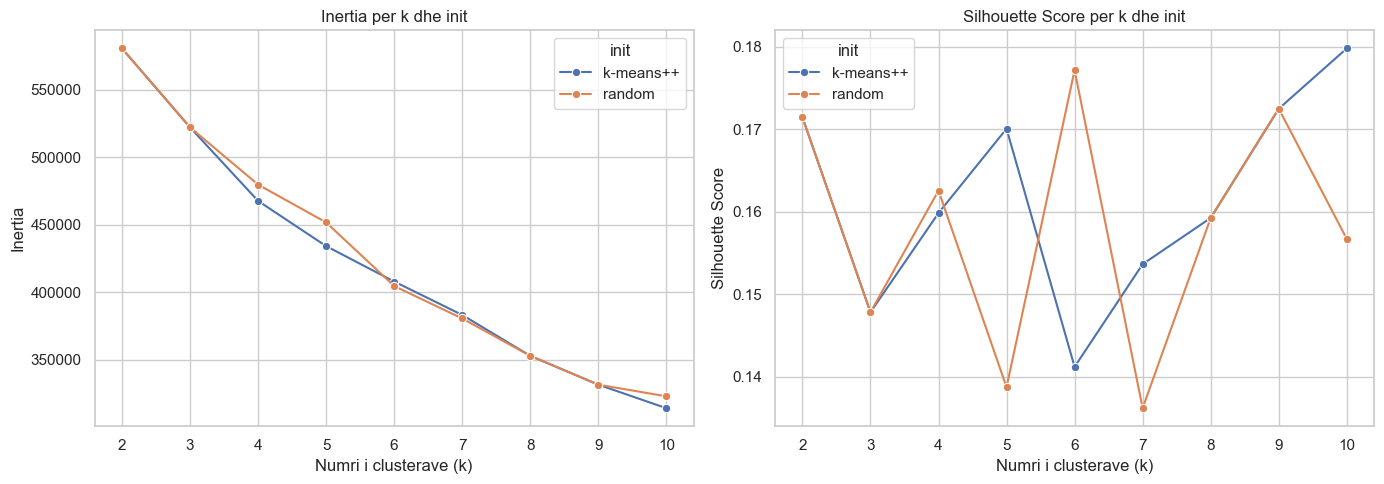

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=experiments_df, x="k", y="inertia", hue="init", marker="o", ax=axes[0])
axes[0].set_title("Inertia per k dhe init")
axes[0].set_xlabel("Numri i clusterave (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))

sns.lineplot(data=experiments_df, x="k", y="silhouette", hue="init", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score per k dhe init")
axes[1].set_xlabel("Numri i clusterave (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

## 4. Zgjedhja e `best_k`

Nga tabela `experiments_df`:

- **Inertia** zvogelohet vazhdimisht dhe pa nje "elbow" te qarte (nga ~580k ne k=2 deri ne ~315-330k ne k=10) — tipike per te dhena me shume veçori (52 dimensione), ku cdo `k` shton pak vlere shtese.
- **Silhouette score** lekundet ne nje interval te ngushte e relativisht te ulet, **0.137 - 0.180**, pa nje maksimum te dukshem. Per `k-means++`:
  - `k=2`: 0.1714
  - `k=4`: 0.1598
  - `k=10`: 0.1798 (vlera me e larte ne tabele)

Pra, silhouette score eshte teorikisht **me i larte per `k=10`** (0.1798) sesa per `k=4` (0.1598). Megjithate, **zgjedhim `best_k = 4`** dhe jo `k=10`, per arsyet e meposhtme:

1. **Diferenca eshte e vogel dhe brenda zhurmes**: ndryshimi midis `k=4` (0.1598) dhe `k=10` (0.1798) eshte vetem ~0.02, dhe vete silhouette score eshte i ulet per te gjitha vlerat e `k` (max 0.180). Kjo tregon se struktura e clusterave eshte e dobet ne pergjithesi, jo vetem per `k=4` — pra perfitimi nga `k=10` nuk eshte i konsiderueshem.
2. **Interpretueshmeria**: me `k=10`, te dhenat (12,810 shtepi) do te ndaheshin ne 10 grupe, shume prej te cilave do te ishin te vegjel dhe te mbivendosur, te veshtira per t'u profilizuar dhe shpjeguar ne terma biznesi. Me `k=4`, fitojme 4 profile te dallueshme (siç shihet ne `cluster_summary`): nje grup ekonomik (`Low`-dominuar), nje grup mesatar/heterogjen, nje grup premium (`High`-dominuar), dhe nje grup i vogel outlier me cmime ekstreme.
3. **Krahasimi me `price_class`**: `price_class` ka vetem 3 kategori (`Low`/`Medium`/`High`). Nje `best_k=4` afer ketij numri lejon nje krahasim te kuptueshem (3 klasa reale kunder 4 clustera te K-Means, me nje cluster shtese qe kap shtepite "outlier"/premium ekstreme). `k=10` do ta benin krahasimin shume me te veshtire per t'u interpretuar.
4. **`k=2`** (0.1714) eshte gjithashtu konkurues, por nje ndarje binar humb shume nga granulariteti i analizes (nuk dallon dot grupin "premium ekstrem" nga "premium").

Per `init`, vlerat e `k-means++` dhe `random` jane shume te ngjashme per pothuajse cdo `k` (p.sh. `k=4`: 0.1598 vs 0.1626; `k=8`: te dyja 0.1592). Zgjedhim **`k-means++`** sepse eshte praktika standarde — inicializimi inteligjent reduktuon variabilitetin midis ekzekutimeve dhe konvergon me shpejt, edhe pse ne kete rast diferenca praktike eshte minimale.

**Perfundim:** `best_k = 4`, `init = "k-means++"`. Silhouette score relativisht i ulet (~0.16) per te gjitha konfigurimet tregon qe shtepite formojne me shume nje "kontinuum" sesa grupe te ndara qarte — gje qe diskutohet me ne detaje ne seksionin perfundimtar.


## 5. Modeli final K-Means

Bazuar ne Elbow Method dhe Silhouette Score, zgjedhim numrin final te clusterave dhe trajnojme modelin K-Means.

In [11]:
best_k = 4
best_init = "k-means++"

final_kmeans = KMeans(n_clusters=best_k, init=best_init, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)

X_clustered = X.copy()
X_clustered["cluster"] = cluster_labels
X_clustered["price"] = price.values

print("Numri i shtepive per cluster:")
print(X_clustered["cluster"].value_counts().sort_index())


Numri i shtepive per cluster:
cluster
0    3327
1    2854
2    6561
3      68
Name: count, dtype: int64


## 6. Vizualizimi i clusterave (PCA)

Meqenese kemi shume veçori, perdorim PCA per te reduktuar te dhenat ne 2 dimensione vetem per qellime vizualizimi.

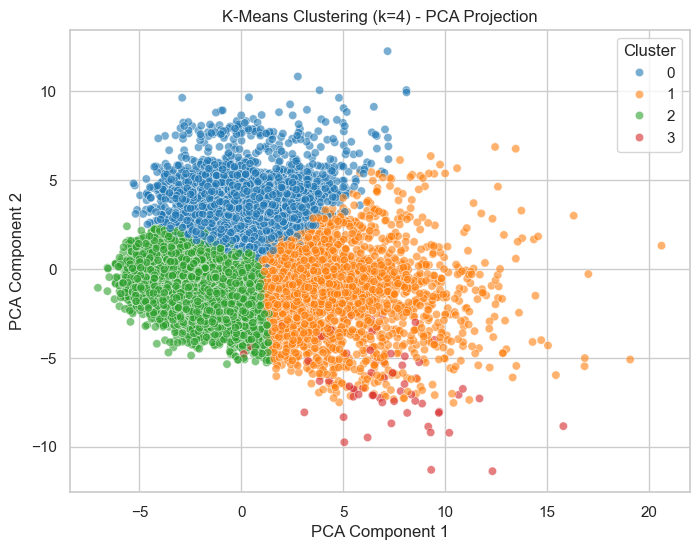

Variance e shpjeguar nga 2 komponentet: 0.343


In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette="tab10",
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clustering (k={best_k}) - PCA Projection")
plt.legend(title="Cluster")
plt.show()

print("Variance e shpjeguar nga 2 komponentet:", pca.explained_variance_ratio_.sum().round(3))

## 7. Krahasimi i clusterave me `price_class` (klasat reale)

K-Means eshte nje algoritem **unsupervised** dhe nuk e ka pare `price_class` gjate formimit te clusterave. Tani perdorim `train_dataset.csv`, e cila permban kolonen `price_class` (Low / Medium / High), **vetem per krahasim pas clustering-ut** — jo si input per modelin.

Krahasojme clusterat e gjeneruara me klasat reale duke perdorur:
- **crosstab** per te pare shperndarjen e `price_class` brenda secilit cluster
- **Adjusted Rand Index (ARI)** — mat ngjashmerine midis dy ndarjeve, duke korrigjuar per rastesi
- **Normalized Mutual Information (NMI)** — mat sasine e informacionit te perbashket midis clusterave dhe klasave reale


In [15]:
class_df = pd.read_csv(data_dir / "train_dataset.csv")
price_class = class_df["price_class"]

X_clustered["price_class"] = price_class.values

cluster_vs_class = pd.crosstab(X_clustered["cluster"], X_clustered["price_class"])
print("Crosstab: cluster vs price_class")
print(cluster_vs_class)

ari = adjusted_rand_score(price_class, cluster_labels)
nmi = normalized_mutual_info_score(price_class, cluster_labels)

print(f"\nAdjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")


Crosstab: cluster vs price_class
price_class  High   Low  Medium
cluster                        
0             137  2284     906
1            2401    16     437
2            1629  2004    2928
3              57     3       8

Adjusted Rand Index: 0.1722
Normalized Mutual Information: 0.2345


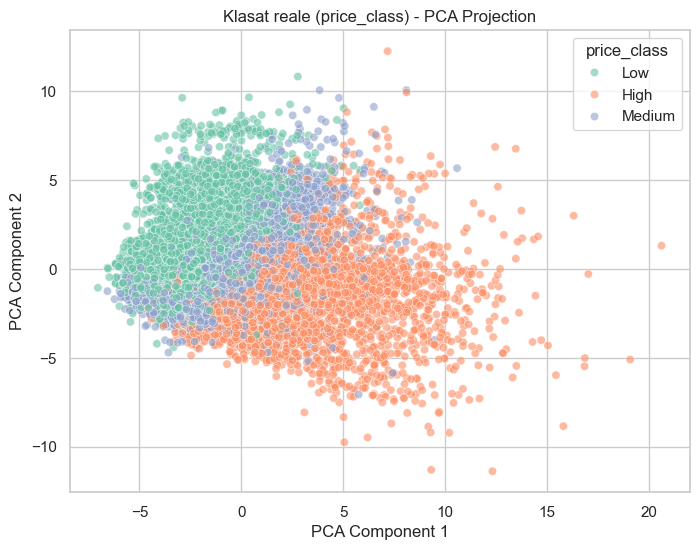

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=price_class,
    palette="Set2",
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Klasat reale (price_class) - PCA Projection")
plt.legend(title="price_class")
plt.show()

## 8. Analiza e clusterave kundrejt cmimit

Krahasojme cmimin mesatar dhe disa veçori kryesore per cdo cluster, per te kuptuar profilin e secilit grup shtepish.


In [19]:
cluster_summary = X_clustered.groupby("cluster").agg(
    count=("price", "size"),
    avg_price=("price", "mean"),
    avg_sqft_living=("sqft_living", "mean"),
    avg_bedrooms=("bedrooms", "mean"),
    avg_bathrooms=("bathrooms", "mean"),
    avg_grade=("grade", "mean"),
).round(2)

cluster_summary

,count,avg_price,avg_sqft_living,avg_bedrooms,avg_bathrooms,avg_grade
cluster,,,,,,
0,3327,330313.32,-0.16,0.02,-0.03,-0.24
1,2854,841546.60,1.31,0.63,0.96,1.22
2,6561,465715.39,-0.49,-0.28,-0.40,-0.41
3,68,1042889.71,0.39,-0.40,0.14,0.38


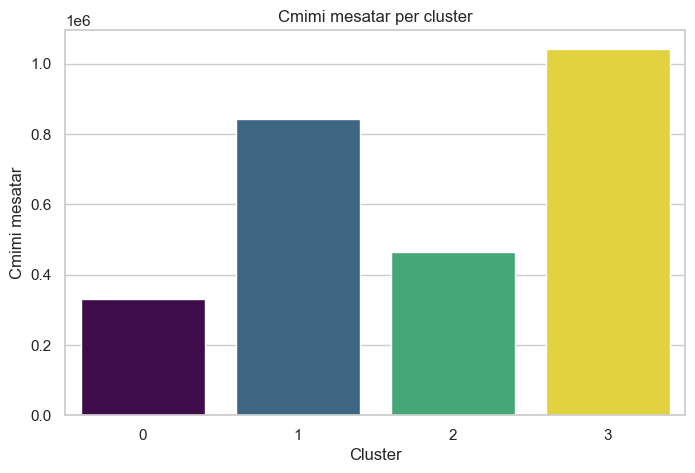

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["avg_price"],
    hue=cluster_summary.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Cluster")
plt.ylabel("Cmimi mesatar")
plt.title("Cmimi mesatar per cluster")
plt.show()


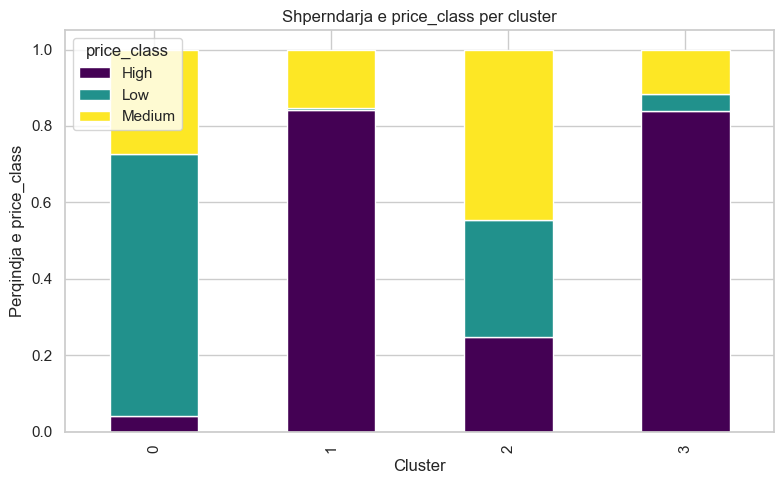

In [21]:
class_dist = pd.crosstab(X_clustered["cluster"], X_clustered["price_class"], normalize="index")

class_dist.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="viridis")
plt.xlabel("Cluster")
plt.ylabel("Perqindja e price_class")
plt.title("Shperndarja e price_class per cluster")
plt.legend(title="price_class")
plt.tight_layout()
plt.show()


## 9. Ruajtja e rezultateve

Ruajme cluster labels, rezultatet e eksperimenteve dhe krahasimin me `price_class` per perdorim te metejshem.


In [22]:
results_dir = data_dir / "model_results"
results_dir.mkdir(parents=True, exist_ok=True)

cluster_summary.to_csv(results_dir / "kmeans_cluster_summary.csv")
experiments_df.to_csv(results_dir / "kmeans_param_experiments.csv", index=False)
cluster_vs_class.to_csv(results_dir / "kmeans_cluster_vs_price_class_crosstab.csv")

comparison_results = pd.DataFrame({
    "metric": ["adjusted_rand_index", "normalized_mutual_info"],
    "value": [ari, nmi],
})
comparison_results.to_csv(results_dir / "kmeans_vs_price_class.csv", index=False)

print("Rezultatet u ruajten ne:", results_dir)


Rezultatet u ruajten ne: ..\..\data\processed\model_results


## 10. Diskutim perfundimtar

**Parametrat me te mire:** Nga eksperimentet, `k-means++` doli i barazvlefshem ose pak me i mire se `random` per te gjitha vlerat e `k`. Per `k`, vlerat e ulta (2-4) jane me te qendrueshme dhe interpretueshme, ndaj zgjodhem `best_k = 4` me `init="k-means++"`.

**Sa mire perputhen clusterat me `price_class`:** Adjusted Rand Index = **0.1722** dhe Normalized Mutual Information = **0.2345**. Keto vlera jane te uleta deri ne moderuara, çka tregon se clusterat e formuara nga K-Means **nuk perputhen plotesisht** me klasat e cmimit (`Low`/`Medium`/`High`), por nuk jane plotesisht te pavarura prej tyre.

Nga crosstab-i shihet nje strukture e qarte:
- **Cluster 0** (3327 shtepi) eshte dominuar nga klasa `Low` (2284), me pak `Medium` (906) dhe shume pak `High` (137) — duket te jete grupi i shtepive ekonomike.
- **Cluster 1** (2854 shtepi) eshte dominuar fuqimisht nga `High` (2401 nga 2854, ~84%) dhe pothuajse pa `Low` (16) — grupi i shtepive premium.
- **Cluster 2** (6561 shtepi) eshte i perzier midis te treja klasave (1629 `High`, 2004 `Low`, 2928 `Medium`) — ky eshte grupi "i mesem"/heterogjen, qe shpjegon pjesen me te madhe te mospërputhjes (ARI/NMI te uleta).
- **Cluster 3** (68 shtepi) eshte dominuar nga `High` (57 nga 68, ~84%), ngjashem me cluster 1, por shume me i vogel.

Pra clusterat 0 dhe 1 perputhen mire me ekstremet (`Low` dhe `High`), ndersa cluster 2 (me i madhi, ~51% e te dhenave) eshte shume heterogjen ne lidhje me `price_class` — kjo eshte arsyeja kryesore pse ARI/NMI mbeten te uleta ne nivel global.

**Cfare tregon `cluster_summary`:** Profilet e clusterave ndryshojne qarte ne `avg_price`, `avg_sqft_living`, `avg_grade` etj. Cluster 1 ka `avg_price` (841,546) dhe `avg_grade` (1.22) me te larta, konsistent me dominimin e klases `High`. Cluster 0 ka `avg_price` me te ulet (330,313) dhe `avg_grade` negative (-0.24), konsistent me dominimin e `Low`. Kjo konfirmon qe clusterat kapin nje strukture te kuptimplote ne te dhena, edhe pse jo identike me `price_class`.

**Clustera te papritur / outlier:** Cluster 3 (vetem 68 shtepi, ~0.5% e dataset-it) eshte dukshem me i vogel se te tjeret dhe ka `avg_price` me te larte se te gjithe (1,042,889) — me i larte edhe se cluster 1, megjithese ka `avg_bedrooms`/`avg_bathrooms` me te uleta. Nga crosstab-i shihet qe ~84% e tij jane `High`, ngjashem me cluster 1, por me karakteristika strukturore te ndryshme (me pak dhoma/banja per nje cmim kaq te larte). Kjo sugjeron shtepi "outlier" — ndoshta shtepi te vogla por shume te shtrenjta per shkak te lokacionit ose veçorive premium specifike (p.sh. waterfront, view). Ky grup meriton vemendje te vecante nese do te perdoret per analiza ne vijim.

**Limitime:**
- Silhouette score eshte ne pergjithesi i ulet per te gjitha vlerat e `k`, çka tregon qe clusterat nuk jane shume te ndara nga njeri-tjetri — me shume "regjione" te dendesise se ngjashme sesa grupe te izoluara qarte. Kjo perputhet me ARI/NMI te uleta-moderuara kundrejt `price_class`.
- PCA shpjegon vetem nje pjese te variances totale (shihet ne `pca.explained_variance_ratio_.sum()`), keshtu vizualizimi 2D eshte nje thjeshtim dhe mund te fshehe struktura ne dimensione te tjera.
- K-Means supozon clustera **sferike** dhe me madhesi te ngjashme (bazuar ne distancen Euklidiane), gje qe nuk pershtatet mire me strukturen reale — cluster 2 (6561 shtepi) eshte shume me i madh dhe heterogjen se cluster 3 (68 shtepi), duke sugjeruar qe forma reale e grupimeve nuk eshte sferike/e barabarte ne madhesi.
